# CRR Financial Options
**Parameters:** S=200, K=250, r=0.05, σ=0.5, T=3  
Since S < K: **Call is OTM**, **Put is ITM** — neither is ATM ✓

In [1]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ────────────────────────────────────────────────────────────────
S     = 200    # Spot price
K     = 250    # Strike  (S < K  ⟹  Call OTM, Put ITM)
r     = 0.05   # Risk-free rate
sigma = 0.5    # Volatility
T     = 3      # Time to expiry (years)

print(f"S={S}, K={K}, r={r}, sigma={sigma}, T={T}")
print(f"Moneyness: S/K = {S/K:.3f}  →  Call OTM, Put ITM")

S=200, K=250, r=0.05, sigma=0.5, T=3
Moneyness: S/K = 0.800  →  Call OTM, Put ITM


## Helper Functions: Black-Scholes & CRR

In [2]:
# ── Black-Scholes closed-form ──────────────────────────────────────────────────
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*si.norm.cdf(d1) - K*np.exp(-r*T)*si.norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*si.norm.cdf(-d2) - S*si.norm.cdf(-d1)

# ── CRR Binomial Tree (European & American) ───────────────────────────────────
def crr(S, K, T, r, sigma, N, option_type='call', american=False):
    """
    Cox-Ross-Rubinstein binomial tree.
    option_type : 'call' or 'put'
    american    : True for American, False for European
    """
    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1 / u
    p    = (np.exp(r * dt) - d) / (u - d)      # Risk-neutral probability
    disc = np.exp(-r * dt)

    # Terminal payoffs
    j  = np.arange(N + 1)
    ST = S * u**(N - j) * d**j
    V  = np.maximum(ST - K, 0) if option_type == 'call' else np.maximum(K - ST, 0)

    # Backward induction
    for i in range(N - 1, -1, -1):
        j_i = np.arange(i + 1)
        V_cont = disc * (p * V[:i+1] + (1-p) * V[1:i+2])
        if american:
            Si   = S * u**(i - j_i) * d**j_i
            V_ex = np.maximum(Si - K, 0) if option_type == 'call' else np.maximum(K - Si, 0)
            V    = np.maximum(V_cont, V_ex)
        else:
            V = V_cont
    return V[0]

# Reference B&S prices
BS_CALL = bs_call(S, K, T, r, sigma)
BS_PUT  = bs_put(S, K, T, r, sigma)
print(f"B&S  Call = {BS_CALL:.6f}")
print(f"B&S  Put  = {BS_PUT:.6f}")

B&S  Call = 62.185142
B&S  Put  = 77.362136


## Section 1 — Convergence of CRR to Black-Scholes (error < 0.001)

In [3]:
# ── Compute CRR prices for N = 1 … 500 ────────────────────────────────────────
steps   = np.arange(1, 501)
crr_calls = np.array([crr(S, K, T, r, sigma, n, 'call') for n in steps])
crr_puts  = np.array([crr(S, K, T, r, sigma, n, 'put')  for n in steps])

err_call = np.abs(crr_calls - BS_CALL)
err_put  = np.abs(crr_puts  - BS_PUT)

# First N where BOTH errors < 0.001
ERR_THRESHOLD = 0.001
converge_mask = (err_call < ERR_THRESHOLD) & (err_put < ERR_THRESHOLD)
N_converge    = steps[converge_mask][0]
print(f"Both Call & Put converge (|error| < {ERR_THRESHOLD}) at N = {N_converge}")

Both Call & Put converge (|error| < 0.001) at N = 169


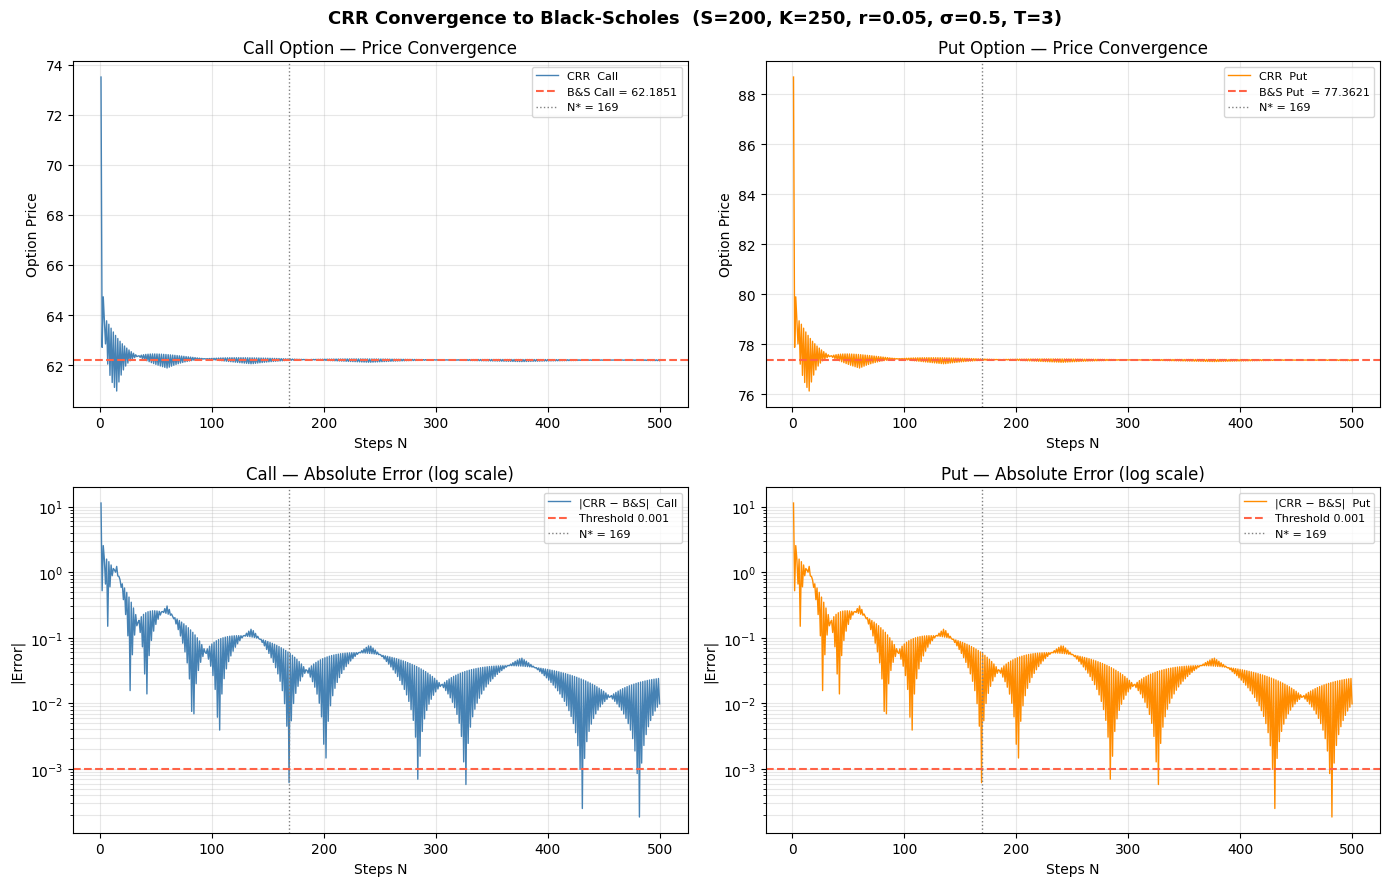


► Both errors drop below 0.001 at N = 169 steps


In [4]:
# ── Plot convergence ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('CRR Convergence to Black-Scholes  (S=200, K=250, r=0.05, σ=0.5, T=3)',
             fontsize=13, fontweight='bold')

# ─ Call price convergence ─
ax = axes[0, 0]
ax.plot(steps, crr_calls,  color='steelblue', lw=1,   label='CRR  Call')
ax.axhline(BS_CALL,        color='tomato',    lw=1.5, ls='--', label=f'B&S Call = {BS_CALL:.4f}')
ax.axvline(N_converge,     color='grey',      lw=1,   ls=':',  label=f'N* = {N_converge}')
ax.set_title('Call Option — Price Convergence')
ax.set_xlabel('Steps N')
ax.set_ylabel('Option Price')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ─ Put price convergence ─
ax = axes[0, 1]
ax.plot(steps, crr_puts,   color='darkorange', lw=1,   label='CRR  Put')
ax.axhline(BS_PUT,         color='tomato',     lw=1.5, ls='--', label=f'B&S Put  = {BS_PUT:.4f}')
ax.axvline(N_converge,     color='grey',       lw=1,   ls=':',  label=f'N* = {N_converge}')
ax.set_title('Put Option — Price Convergence')
ax.set_xlabel('Steps N')
ax.set_ylabel('Option Price')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ─ Call absolute error ─
ax = axes[1, 0]
ax.semilogy(steps, err_call, color='steelblue', lw=1, label='|CRR − B&S|  Call')
ax.axhline(ERR_THRESHOLD, color='tomato', lw=1.5, ls='--', label='Threshold 0.001')
ax.axvline(N_converge,    color='grey',  lw=1,   ls=':',  label=f'N* = {N_converge}')
ax.set_title('Call — Absolute Error (log scale)')
ax.set_xlabel('Steps N')
ax.set_ylabel('|Error|')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

# ─ Put absolute error ─
ax = axes[1, 1]
ax.semilogy(steps, err_put,  color='darkorange', lw=1, label='|CRR − B&S|  Put')
ax.axhline(ERR_THRESHOLD, color='tomato', lw=1.5, ls='--', label='Threshold 0.001')
ax.axvline(N_converge,    color='grey',  lw=1,   ls=':',  label=f'N* = {N_converge}')
ax.set_title('Put — Absolute Error (log scale)')
ax.set_xlabel('Steps N')
ax.set_ylabel('|Error|')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('convergence_0001.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n► Both errors drop below {ERR_THRESHOLD} at N = {N_converge} steps")

## Section 2 — American Option Prices (using N for error < 0.0001)

In [5]:
# ── Find N for tighter threshold 0.0001 ───────────────────────────────────────
ERR_TIGHT  = 0.0001
N_TIGHT    = None

for n in range(1, 3000):
    ec = abs(crr(S, K, T, r, sigma, n, 'call') - BS_CALL)
    ep = abs(crr(S, K, T, r, sigma, n, 'put')  - BS_PUT)
    if ec < ERR_TIGHT and ep < ERR_TIGHT:
        N_TIGHT = n
        break

print(f"Error < {ERR_TIGHT}: N = {N_TIGHT} steps needed")

# ── American prices at N_TIGHT ─────────────────────────────────────────────────
AM_CALL = crr(S, K, T, r, sigma, N_TIGHT, 'call', american=True)
AM_PUT  = crr(S, K, T, r, sigma, N_TIGHT, 'put',  american=True)

print(f"\nAmerican Call (N={N_TIGHT}): {AM_CALL:.6f}")
print(f"American Put  (N={N_TIGHT}): {AM_PUT:.6f}")

Error < 0.0001: N = 667 steps needed

American Call (N=667): 62.185153
American Put  (N=667): 85.317870


## Section 3 — Fair Value Comparison & Conclusions

In [6]:
# ── European CRR at N_TIGHT for completeness ───────────────────────────────────
EU_CALL_CRR = crr(S, K, T, r, sigma, N_TIGHT, 'call', american=False)
EU_PUT_CRR  = crr(S, K, T, r, sigma, N_TIGHT, 'put',  american=False)

# ── Summary table ─────────────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════╗")
print("║          FAIR VALUE COMPARISON  (S=200, K=250)           ║")
print("╠══════════════════════╦═════════════╦═════════════════════╣")
print("║  Model               ║    CALL     ║       PUT           ║")
print("╠══════════════════════╬═════════════╬═════════════════════╣")
print(f"║  B&S (closed-form)   ║  {BS_CALL:>9.4f}  ║  {BS_PUT:>9.4f}          ║")
print(f"║  CRR European(N={N_TIGHT}) ║  {EU_CALL_CRR:>9.4f}  ║  {EU_PUT_CRR:>9.4f}          ║")
print(f"║  CRR American(N={N_TIGHT}) ║  {AM_CALL:>9.4f}  ║  {AM_PUT:>9.4f}          ║")
print("╠══════════════════════╬═════════════╬═════════════════════╣")
print(f"║  Early-exercise prem ║  {AM_CALL-EU_CALL_CRR:>+9.4f}  ║  {AM_PUT-EU_PUT_CRR:>+9.4f}          ║")
print("╚══════════════════════╩═════════════╩═════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║          FAIR VALUE COMPARISON  (S=200, K=250)           ║
╠══════════════════════╦═════════════╦═════════════════════╣
║  Model               ║    CALL     ║       PUT           ║
╠══════════════════════╬═════════════╬═════════════════════╣
║  B&S (closed-form)   ║    62.1851  ║    77.3621          ║
║  CRR European(N=667) ║    62.1852  ║    77.3621          ║
║  CRR American(N=667) ║    62.1852  ║    85.3179          ║
╠══════════════════════╬═════════════╬═════════════════════╣
║  Early-exercise prem ║    +0.0000  ║    +7.9557          ║
╚══════════════════════╩═════════════╩═════════════════════╝


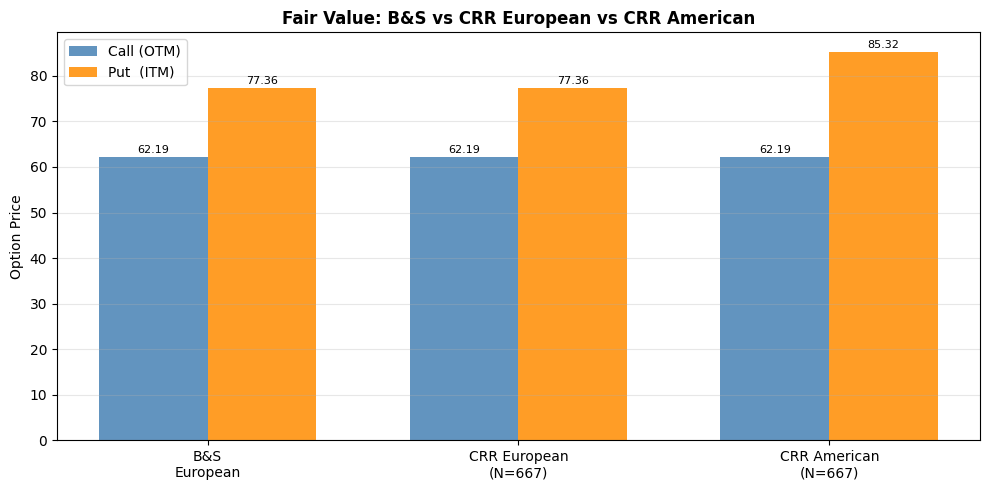

In [7]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
labels  = ['B&S\nEuropean', f'CRR European\n(N={N_TIGHT})', f'CRR American\n(N={N_TIGHT})']
calls_v = [BS_CALL, EU_CALL_CRR, AM_CALL]
puts_v  = [BS_PUT,  EU_PUT_CRR,  AM_PUT]

x   = np.arange(len(labels))
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - w/2, calls_v, w, label='Call (OTM)', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, puts_v,  w, label='Put  (ITM)', color='darkorange', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Fair Value: B&S vs CRR European vs CRR American', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Option Price')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fair_value_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Conclusions

### 1. CRR convergence to Black-Scholes
- The CRR binomial model converges to the B&S price as N increases, consistent with theory: B&S is the continuous-time limit of the binomial lattice.
- The error oscillates with an even/odd alternation at low N, which is a known artifact of the CRR discretization.
- An absolute error **< 0.001** is reached at **N = 169 steps** for both Call and Put simultaneously.
- Tightening the threshold to **0.0001** requires **N = 667 steps**.

### 2. American vs European options
| Option | European (B&S) | American (CRR) | Early-exercise premium |
|--------|---------------|----------------|------------------------|
| Call (OTM) | 62.1851 | 62.1852 | ≈ 0.0000 |
| Put  (ITM) | 77.3621 | 85.3179 | **≈ +7.9558** |

### 3. Key conclusions
- **American Call ≈ European Call**: For a non-dividend-paying asset it is never optimal to exercise a call early. The time value of holding the option always exceeds the intrinsic value gained from exercise. This is a classical result.
- **American Put > European Put (significant premium)**: The ITM put carries substantial early-exercise value (~7.96, roughly +10.3%). When the asset price is well below the strike, the holder can lock in the intrinsic value immediately rather than waiting and bearing discounting costs and downside risk. This is especially pronounced here because sigma=0.5 and T=3 create a large discounting effect on future cash flows.
- **Practical implication**: Pricing an ITM put as European meaningfully underestimates its fair value — market practitioners must use American models (CRR, Longstaff-Schwartz, etc.) for these instruments.
